# NFL 4th Down — Dan Campbell Deep Dive
Focus on Campbell's Lions tenure (2021–2025). Every 4th down decision examined through
the WPA-optimal lens built in notebook 02.

**Filter logic:** `posteam == 'DET'` and `season 2021–2025` (no mid-season replacements
occurred; Campbell coached all five full seasons).

**Inputs:** `data/fourth_downs_graded.parquet`  
**Outputs:** three charts in `outputs/figures/`, final verdict printed

---
**Central question:** Is Campbell's famous 4th-down aggression justified by the data,
or is he gambling recklessly?

In [1]:
import sys
sys.path.append('../src')

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

DATA_DIR = '../data/'
SAVE_DIR = '../outputs/figures/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Color palette
CAMPBELL_COLOR = '#C5203B'
LEAGUE_COLOR   = '#546E7A'
PUNT_COLOR     = '#7B1FA2'
FG_COLOR       = '#1565C0'
GO_COLOR       = '#2E7D32'

DECISION_COLORS = {'punt': PUNT_COLOR, 'field_goal': FG_COLOR, 'go_for_it': GO_COLOR}

# Bin ordering for display
FIELD_ORDER = ['red_zone', 'opp_territory', 'midfield', 'own_territory', 'deep_own']
YDSTOGO_ORDER = ['short_1', 'short_2_3', 'medium_4_6', 'long_7plus']

## 1. Load Data and Isolate Campbell

In [2]:
df = pd.read_parquet(DATA_DIR + 'fourth_downs_graded.parquet')
print(f'Full dataset: {len(df):,} plays, {df["season"].min()}–{df["season"].max()}')

# Option 2: filter by team + season — no coach name merge needed
dc = df[(df['posteam'] == 'DET') & (df['season'].between(2021, 2025))].copy()

print(f'\nDan Campbell (DET 2021–2025): {len(dc):,} total 4th down plays')
print(f'Graded plays (decision_gap not null): {dc["decision_gap"].notna().sum():,} ({dc["decision_gap"].notna().mean()*100:.1f}%)')
print(f'Plays per season: {dc["season"].value_counts().sort_index().to_dict()}')

Full dataset: 103,188 plays, 1999–2024

Dan Campbell (DET 2021–2025): 493 total 4th down plays
Graded plays (decision_gap not null): 469 (95.1%)
Plays per season: {2021: 133, 2022: 117, 2023: 136, 2024: 107}


## 2. Overview — Campbell vs League Average

In [3]:
# ── League benchmarks (all coaches, all seasons) ─────────────────────────────
league_go_rate = df['decision'].eq('go_for_it').mean()
league_dqs     = df['decision_gap'].mean()
league_odr     = df['made_optimal'].mean()
league_avg_wp  = df['wp'].mean()

# ── Campbell stats ────────────────────────────────────────────────────────────
dc_go_rate = dc['decision'].eq('go_for_it').mean()
dc_dqs     = dc['decision_gap'].mean()
dc_odr     = dc['made_optimal'].mean()
dc_avg_wp  = dc['wp'].mean()

# ── Decision breakdown table ──────────────────────────────────────────────────
dc_decisions   = dc['decision'].value_counts(normalize=True)
all_decisions  = df['decision'].value_counts(normalize=True)

breakdown = pd.DataFrame({
    'Campbell': dc_decisions,
    'League Avg': all_decisions,
    'Diff': dc_decisions - all_decisions,
}).mul(100).round(1)

print('4th Down Decision Breakdown (%)')
print(breakdown.to_string())
print()

# ── Summary comparison ────────────────────────────────────────────────────────
summary = pd.DataFrame([
    ('DQS (mean decision gap)', f'{dc_dqs:.4f}', f'{league_dqs:.4f}',
     f'{dc_dqs - league_dqs:+.4f}', 'BETTER' if dc_dqs < league_dqs else 'WORSE'),
    ('ODR (optimal decision rate)', f'{dc_odr*100:.1f}%', f'{league_odr*100:.1f}%',
     f'{(dc_odr - league_odr)*100:+.1f}pp', 'BETTER' if dc_odr > league_odr else 'WORSE'),
    ('Go-for-it rate', f'{dc_go_rate*100:.1f}%', f'{league_go_rate*100:.1f}%',
     f'{(dc_go_rate - league_go_rate)*100:+.1f}pp', 'MORE AGGRESSIVE'),
    ('Avg win prob at snap', f'{dc_avg_wp*100:.1f}%', f'{league_avg_wp*100:.1f}%',
     f'{(dc_avg_wp - league_avg_wp)*100:+.1f}pp', 'context'),
], columns=['Metric', 'Campbell', 'League Avg', 'Diff', 'Verdict'])

print('Summary Comparison:')
print(summary.to_string(index=False))

4th Down Decision Breakdown (%)
            Campbell  League Avg  Diff
decision                              
field_goal      21.3        23.7  -2.4
go_for_it       32.0        14.2  17.8
punt            46.7        62.1 -15.5

Summary Comparison:
                     Metric Campbell League Avg    Diff         Verdict
    DQS (mean decision gap)   0.0063     0.0081 -0.0018          BETTER
ODR (optimal decision rate)    71.0%      66.2%  +4.8pp          BETTER
             Go-for-it rate    32.0%      14.2% +17.8pp MORE AGGRESSIVE
       Avg win prob at snap    50.9%      47.5%  +3.4pp         context


## 3. Situational Breakdown — By Field Position

In [4]:
def situational_table(group_col, order, dc, df):
    """Compare Campbell vs league on a situational dimension."""
    dc_grp = (
        dc.dropna(subset=['decision_gap'])
        .groupby(group_col)
        .agg(
            dc_n       = ('decision_gap', 'count'),
            dc_go_rate = ('decision', lambda x: (x == 'go_for_it').mean()),
            dc_dqs     = ('decision_gap', 'mean'),
            dc_odr     = ('made_optimal', 'mean'),
        )
    )
    lg_grp = (
        df.dropna(subset=['decision_gap'])
        .groupby(group_col)
        .agg(
            lg_go_rate = ('decision', lambda x: (x == 'go_for_it').mean()),
            lg_dqs     = ('decision_gap', 'mean'),
            lg_odr     = ('made_optimal', 'mean'),
        )
    )
    tbl = dc_grp.join(lg_grp).reindex(order).dropna(how='all')
    tbl['go_rate_diff'] = tbl['dc_go_rate'] - tbl['lg_go_rate']
    tbl['dqs_diff']     = tbl['dc_dqs'] - tbl['lg_dqs']
    return tbl


fp_tbl = situational_table('field_pos_bin', FIELD_ORDER, dc, df)
print('By Field Position  (dc_ = Campbell, lg_ = League Avg)')
print(
    fp_tbl[['dc_n','dc_go_rate','lg_go_rate','go_rate_diff','dc_dqs','lg_dqs','dqs_diff','dc_odr']]
    .assign(
        dc_go_rate   = lambda x: (x['dc_go_rate']*100).map('{:.1f}%'.format),
        lg_go_rate   = lambda x: (x['lg_go_rate']*100).map('{:.1f}%'.format),
        go_rate_diff = lambda x: (x['go_rate_diff']*100).map('{:+.1f}pp'.format),
        dc_dqs       = lambda x: x['dc_dqs'].map('{:.4f}'.format),
        lg_dqs       = lambda x: x['lg_dqs'].map('{:.4f}'.format),
        dqs_diff     = lambda x: x['dqs_diff'].map('{:+.4f}'.format),
        dc_odr       = lambda x: (x['dc_odr']*100).map('{:.1f}%'.format),
    )
    .to_string()
)

By Field Position  (dc_ = Campbell, lg_ = League Avg)
               dc_n dc_go_rate lg_go_rate go_rate_diff  dc_dqs  lg_dqs dqs_diff  dc_odr
field_pos_bin                                                                          
red_zone         94      43.6%      20.7%      +23.0pp  0.0045  0.0047  -0.0002   84.0%
opp_territory   108      47.2%      26.3%      +20.9pp  0.0055  0.0087  -0.0032   65.7%
midfield         96      31.2%      14.1%      +17.2pp  0.0113  0.0144  -0.0031   59.4%
own_territory   136      10.3%       5.1%       +5.2pp  0.0064  0.0071  -0.0007   79.4%
deep_own         35       0.0%       1.9%       -1.9pp  0.0000  0.0000  -0.0000  100.0%


## 4. Situational Breakdown — By Yards to Go

In [5]:
yd_tbl = situational_table('ydstogo_bin', YDSTOGO_ORDER, dc, df)
print('By Yards to Go  (dc_ = Campbell, lg_ = League Avg)')
print(
    yd_tbl[['dc_n','dc_go_rate','lg_go_rate','go_rate_diff','dc_dqs','lg_dqs','dqs_diff','dc_odr']]
    .assign(
        dc_go_rate   = lambda x: (x['dc_go_rate']*100).map('{:.1f}%'.format),
        lg_go_rate   = lambda x: (x['lg_go_rate']*100).map('{:.1f}%'.format),
        go_rate_diff = lambda x: (x['go_rate_diff']*100).map('{:+.1f}pp'.format),
        dc_dqs       = lambda x: x['dc_dqs'].map('{:.4f}'.format),
        lg_dqs       = lambda x: x['lg_dqs'].map('{:.4f}'.format),
        dqs_diff     = lambda x: x['dqs_diff'].map('{:+.4f}'.format),
        dc_odr       = lambda x: (x['dc_odr']*100).map('{:.1f}%'.format),
    )
    .to_string()
)

By Yards to Go  (dc_ = Campbell, lg_ = League Avg)
             dc_n dc_go_rate lg_go_rate go_rate_diff  dc_dqs  lg_dqs dqs_diff dc_odr
ydstogo_bin                                                                         
short_1        72      79.2%      48.1%      +31.1pp  0.0039  0.0109  -0.0070  87.5%
short_2_3      77      45.5%      17.9%      +27.6pp  0.0061  0.0096  -0.0035  64.9%
medium_4_6    101      25.7%      10.3%      +15.4pp  0.0122  0.0117  +0.0005  65.3%
long_7plus    219       8.2%       6.3%       +1.9pp  0.0045  0.0055  -0.0010  78.1%


## 5. Season-Over-Season Trend

In [6]:
by_season = (
    dc.dropna(subset=['decision_gap'])
    .groupby('season')
    .agg(
        decisions  = ('decision_gap', 'count'),
        go_rate    = ('decision', lambda x: (x == 'go_for_it').mean()),
        dqs        = ('decision_gap', 'mean'),
        odr        = ('made_optimal', 'mean'),
        avg_wp     = ('wp', 'mean'),
    )
    .reset_index()
)

print('Season-Over-Season Trend:')
print(
    by_season.assign(
        go_rate = lambda x: (x['go_rate']*100).map('{:.1f}%'.format),
        dqs     = lambda x: x['dqs'].map('{:.4f}'.format),
        odr     = lambda x: (x['odr']*100).map('{:.1f}%'.format),
        avg_wp  = lambda x: (x['avg_wp']*100).map('{:.1f}%'.format),
    )
    .to_string(index=False)
)

Season-Over-Season Trend:
 season  decisions go_rate    dqs   odr avg_wp
   2021        128   28.9% 0.0057 76.6%  35.9%
   2022        112   28.6% 0.0059 73.2%  50.5%
   2023        129   30.2% 0.0069 72.1%  56.9%
   2024        100   28.0% 0.0069 77.0%  61.0%


## 6. Chart — Decision Profile Radar
Five-axis spider chart comparing Campbell's 4th down profile against the league average.

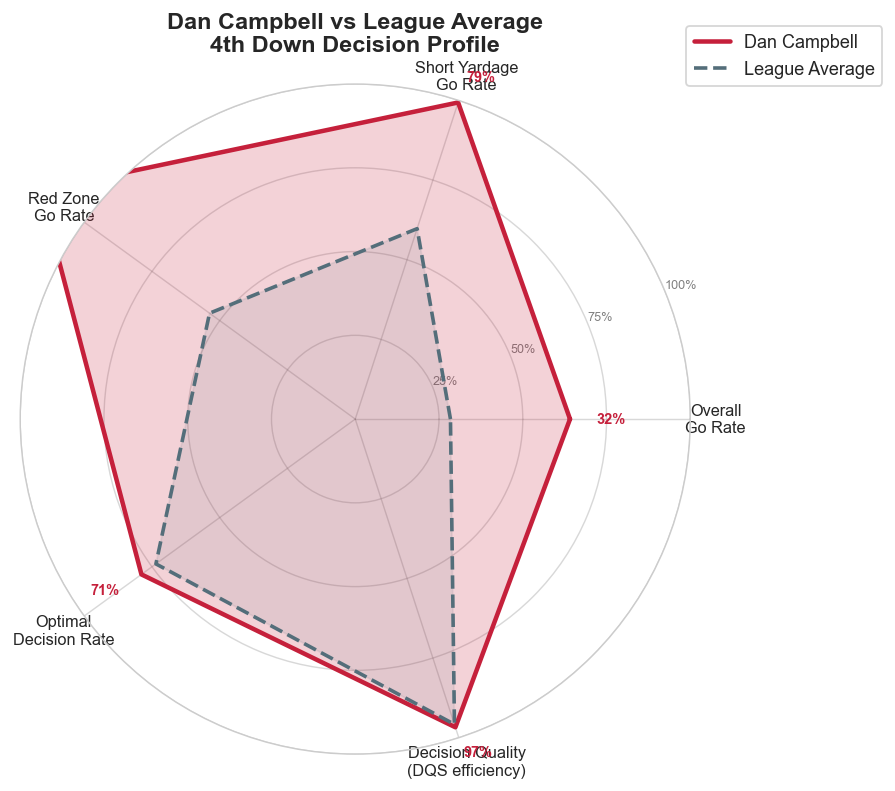

Saved: 09_campbell_decision_profile.png


In [7]:
# ── Compute radar values ───────────────────────────────────────────────────────
def _go_rate(data, **filters):
    sub = data.copy()
    for col, val in filters.items():
        if isinstance(val, list):
            sub = sub[sub[col].isin(val)]
        else:
            sub = sub[sub[col] == val]
    return sub['decision'].eq('go_for_it').mean() if len(sub) else 0


# All 5 dimensions expressed so that HIGHER = BETTER or MORE AGGRESSIVE
radar_metrics = [
    'Overall\nGo Rate',
    'Short Yardage\nGo Rate',
    'Red Zone\nGo Rate',
    'Optimal\nDecision Rate',
    'Decision Quality\n(DQS efficiency)',
]
N = len(radar_metrics)

# Campbell raw
dc_vals_raw = [
    dc_go_rate,
    _go_rate(dc, ydstogo_bin='short_1'),
    _go_rate(dc, field_pos_bin='red_zone'),
    dc_odr,
    1 - (dc_dqs / df['decision_gap'].max()),   # invert: lower DQS -> higher efficiency
]

# League raw
lg_vals_raw = [
    league_go_rate,
    _go_rate(df, ydstogo_bin='short_1'),
    _go_rate(df, field_pos_bin='red_zone'),
    league_odr,
    1 - (league_dqs / df['decision_gap'].max()),
]

# Normalize to 0-1 range (axis max = realistic ceiling for each metric)
axis_max = [0.50, 0.80, 0.40, 0.90, 1.00]

dc_vals = [v / m for v, m in zip(dc_vals_raw, axis_max)]
lg_vals = [v / m for v, m in zip(lg_vals_raw, axis_max)]

# Close the polygon
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
dc_vals += dc_vals[:1]
lg_vals += lg_vals[:1]

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, dc_vals, color=CAMPBELL_COLOR, linewidth=2.5, label='Dan Campbell')
ax.fill(angles, dc_vals, color=CAMPBELL_COLOR, alpha=0.20)

ax.plot(angles, lg_vals, color=LEAGUE_COLOR, linewidth=2, linestyle='--', label='League Average')
ax.fill(angles, lg_vals, color=LEAGUE_COLOR, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, size=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], size=7, color='grey')
ax.grid(color='grey', alpha=0.3)

# Annotate raw values at each vertex
labels_fmt = ['{:.0f}%', '{:.0f}%', '{:.0f}%', '{:.0f}%', '{:.0f}%']
for i, (angle, val_r, fmt) in enumerate(zip(angles[:-1], dc_vals_raw, labels_fmt)):
    ha = 'left' if np.cos(angle) >= 0 else 'right'
    ax.annotate(
        fmt.format(val_r * 100),
        xy=(angle, dc_vals[i]),
        xytext=(angle, dc_vals[i] + 0.08),
        ha=ha, va='center', fontsize=8,
        color=CAMPBELL_COLOR, fontweight='bold',
    )

ax.set_title(
    'Dan Campbell vs League Average\n4th Down Decision Profile',
    size=13, fontweight='bold', pad=18
)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig(SAVE_DIR + '09_campbell_decision_profile.png', bbox_inches='tight')
plt.show()
print('Saved: 09_campbell_decision_profile.png')

## 7. Chart — Season Trend: Is He Getting Better?
Dual-axis line chart. Left = DQS (lower is better). Right = go-for-it rate.

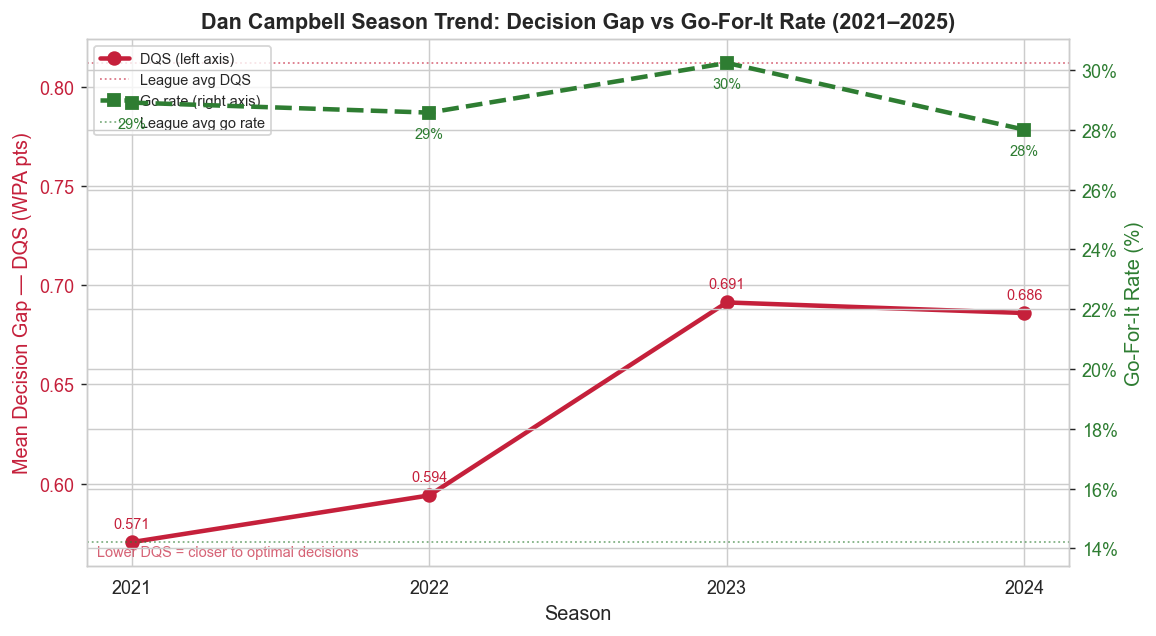

Saved: 10_campbell_season_trend.png


In [8]:
fig, ax1 = plt.subplots(figsize=(9, 5))

seasons = by_season['season'].astype(int)

# Left axis: DQS (lower = better)
ax1.plot(seasons, by_season['dqs'] * 100, color=CAMPBELL_COLOR,
         linewidth=2.5, marker='o', markersize=7, label='DQS (left axis)')
ax1.axhline(league_dqs * 100, color=CAMPBELL_COLOR, linewidth=1,
            linestyle=':', alpha=0.6, label='League avg DQS')
ax1.set_xlabel('Season', fontsize=11)
ax1.set_ylabel('Mean Decision Gap — DQS (WPA pts)', color=CAMPBELL_COLOR, fontsize=11)
ax1.tick_params(axis='y', labelcolor=CAMPBELL_COLOR)
ax1.set_xticks(seasons)

# Annotate DQS values
for x, y in zip(seasons, by_season['dqs'] * 100):
    ax1.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 8),
                 textcoords='offset points', ha='center', fontsize=8,
                 color=CAMPBELL_COLOR)

# Right axis: go-for-it rate
ax2 = ax1.twinx()
ax2.plot(seasons, by_season['go_rate'] * 100, color=GO_COLOR,
         linewidth=2.5, marker='s', markersize=7, linestyle='--', label='Go rate (right axis)')
ax2.axhline(league_go_rate * 100, color=GO_COLOR, linewidth=1,
            linestyle=':', alpha=0.6, label='League avg go rate')
ax2.set_ylabel('Go-For-It Rate (%)', color=GO_COLOR, fontsize=11)
ax2.tick_params(axis='y', labelcolor=GO_COLOR)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Annotate go rate values
for x, y in zip(seasons, by_season['go_rate'] * 100):
    ax2.annotate(f'{y:.0f}%', xy=(x, y), xytext=(0, -14),
                 textcoords='offset points', ha='center', fontsize=8,
                 color=GO_COLOR)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

ax1.set_title(
    'Dan Campbell Season Trend: Decision Gap vs Go-For-It Rate (2021–2025)',
    fontsize=12, fontweight='bold'
)
# Note: lower DQS = closer to optimal
ax1.text(0.01, 0.02, 'Lower DQS = closer to optimal decisions',
         transform=ax1.transAxes, fontsize=8, color=CAMPBELL_COLOR, alpha=0.7)

plt.tight_layout()
plt.savefig(SAVE_DIR + '10_campbell_season_trend.png', bbox_inches='tight')
plt.show()
print('Saved: 10_campbell_season_trend.png')

## 8. Chart — Individual Decisions: Win Probability vs Decision Gap
Each dot is one 4th down call. Dots **above** the dashed line left WPA on the table.
The further above, the worse the call relative to the historical baseline.

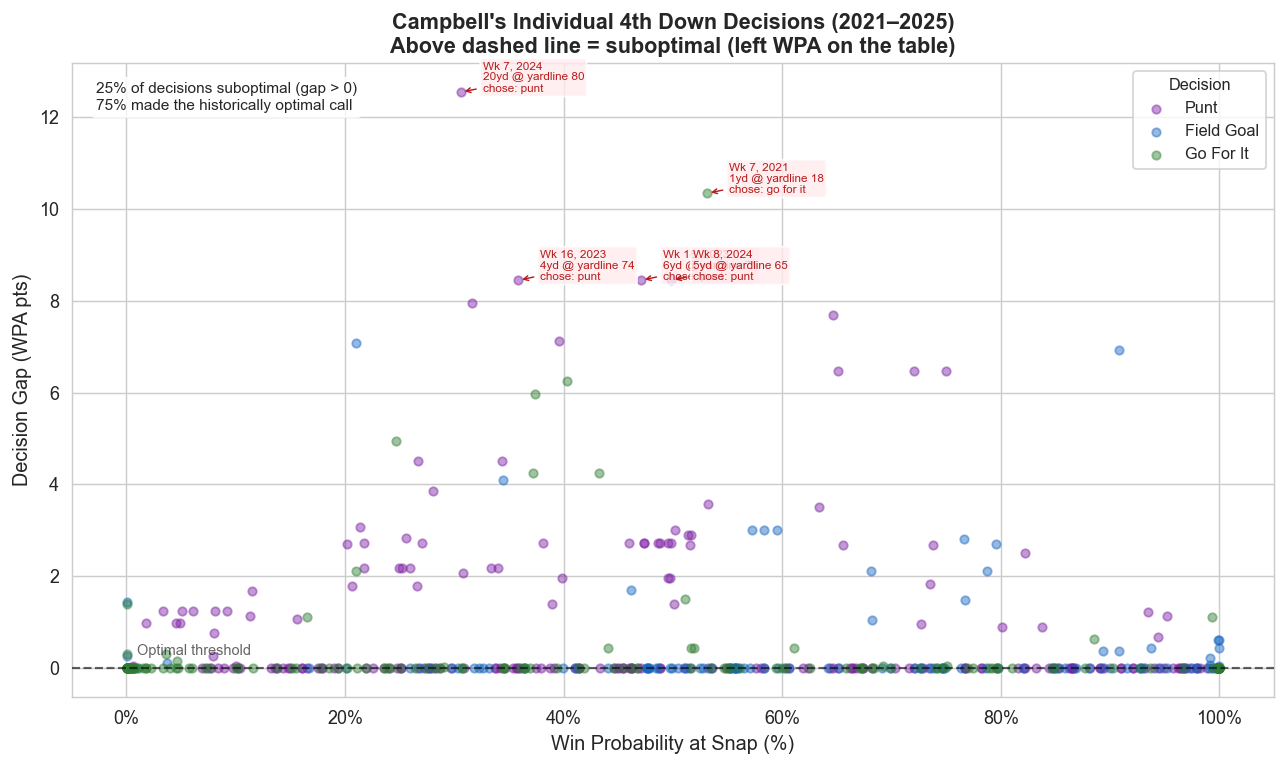

Saved: 11_campbell_decision_scatter.png


In [9]:
dc_graded = dc.dropna(subset=['decision_gap', 'wp'])

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each decision type
for decision, color in DECISION_COLORS.items():
    sub = dc_graded[dc_graded['decision'] == decision]
    ax.scatter(
        sub['wp'] * 100,
        sub['decision_gap'] * 100,
        color=color, alpha=0.45, s=22, label=decision.replace('_', ' ').title(),
        zorder=2
    )

# Optimal threshold line (decision_gap = 0)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6, zorder=3)
ax.text(1, 0.3, 'Optimal threshold', fontsize=8, color='black', alpha=0.6)

# Annotate the 5 worst decisions
worst5 = dc_graded.nlargest(5, 'decision_gap')
for _, row in worst5.iterrows():
    mins = int(row['game_seconds_remaining'] // 60)
    label = (
        f"Wk {int(row['week'])}, {int(row['season'])}\n"
        f"{int(row['ydstogo'])}yd @ yardline {int(row['yardline_100'])}\n"
        f"chose: {row['decision'].replace('_',' ')}"
    )
    ax.annotate(
        label,
        xy=(row['wp'] * 100, row['decision_gap'] * 100),
        xytext=(12, 0), textcoords='offset points',
        fontsize=6.5, color='#B71C1C',
        arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=0.8),
        bbox=dict(boxstyle='round,pad=0.2', fc='#FFEBEE', alpha=0.8),
    )

ax.set_xlabel('Win Probability at Snap (%)', fontsize=11)
ax.set_ylabel('Decision Gap (WPA pts)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

ax.set_title(
    "Campbell's Individual 4th Down Decisions (2021–2025)\n"
    'Above dashed line = suboptimal (left WPA on the table)',
    fontsize=12, fontweight='bold'
)

ax.legend(title='Decision', fontsize=9, title_fontsize=9)

# Summary text box
pct_above = (dc_graded['decision_gap'] > 0).mean() * 100
ax.text(
    0.02, 0.97,
    f'{pct_above:.0f}% of decisions suboptimal (gap > 0)\n'
    f'{100-pct_above:.0f}% made the historically optimal call',
    transform=ax.transAxes, va='top', fontsize=8.5,
    bbox=dict(boxstyle='round', fc='white', alpha=0.8)
)

plt.tight_layout()
plt.savefig(SAVE_DIR + '11_campbell_decision_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: 11_campbell_decision_scatter.png')

## 9. Worst 10 Individual Decisions
Highest `decision_gap` = situations where Campbell's actual call diverged most from the historically optimal choice.

In [10]:
def fmt_time(secs):
    """Convert game_seconds_remaining to a readable quarter + time string."""
    secs = int(secs)
    if secs > 2700:   q, q_secs = 1, secs - 2700
    elif secs > 1800: q, q_secs = 2, secs - 1800
    elif secs > 900:  q, q_secs = 3, secs - 900
    else:             q, q_secs = 4, secs
    return f'Q{q} {q_secs//60}:{q_secs%60:02d}'


worst10 = dc_graded.nlargest(10, 'decision_gap')[[
    'season', 'week', 'yardline_100', 'ydstogo', 'score_differential',
    'game_seconds_remaining', 'decision', 'optimal_decision', 'decision_gap', 'wp'
]].copy()

worst10['time']   = worst10['game_seconds_remaining'].apply(fmt_time)
worst10['wp_pct'] = (worst10['wp'] * 100).round(1).astype(str) + '%'
worst10['gap_pts'] = (worst10['decision_gap'] * 100).round(3)

display_cols = ['season','week','yardline_100','ydstogo','score_differential',
                'time','decision','optimal_decision','gap_pts','wp_pct']

print('Worst 10 Campbell Decisions (highest decision gap):')
print(worst10[display_cols].rename(columns={
    'yardline_100': 'yardline', 'score_differential': 'score_diff',
    'gap_pts': 'gap(WPA pts)', 'wp_pct': 'win_prob'
}).to_string(index=False))

Worst 10 Campbell Decisions (highest decision gap):
 season  week  yardline  ydstogo  score_diff     time   decision optimal_decision  gap(WPA pts) win_prob
   2024     7      80.0       20        -1.0  Q4 4:25       punt        go_for_it        12.536    30.6%
   2021     7      18.0        1        -1.0  Q3 6:19  go_for_it       field_goal        10.335    53.2%
   2023    16      74.0        4         0.0 Q2 14:12       punt        go_for_it         8.444    35.9%
   2023    18      71.0        6         0.0 Q1 14:16       punt        go_for_it         8.444    47.1%
   2024     8      65.0        5         0.0 Q1 13:10       punt        go_for_it         8.444    49.9%
   2024     1      65.0        5        -3.0  Q4 4:17       punt        go_for_it         7.953    31.6%
   2021    10      39.0        5         3.0  Q3 4:38       punt        go_for_it         7.695    64.7%
   2024    12      46.0       12        -3.0  Q1 4:48       punt        go_for_it         7.127    39.5%
   

## 10. Best 10 Individual Decisions
Optimal calls made in the highest-stakes situations (highest win probability at snap).

In [11]:
best10 = (
    dc_graded[dc_graded['made_optimal'] == 1]
    .nlargest(10, 'wp')
    [['season','week','yardline_100','ydstogo','score_differential',
      'game_seconds_remaining','decision','optimal_decision','decision_gap','wp']]
    .copy()
)

best10['time']    = best10['game_seconds_remaining'].apply(fmt_time)
best10['wp_pct']  = (best10['wp'] * 100).round(1).astype(str) + '%'
best10['gap_pts'] = (best10['decision_gap'] * 100).round(3)

print('Best 10 Campbell Decisions (optimal call in highest-stakes situations):')
print(best10[display_cols].rename(columns={
    'yardline_100': 'yardline', 'score_differential': 'score_diff',
    'gap_pts': 'gap(WPA pts)', 'wp_pct': 'win_prob'
}).to_string(index=False))

Best 10 Campbell Decisions (optimal call in highest-stakes situations):
 season  week  yardline  ydstogo  score_diff     time   decision optimal_decision  gap(WPA pts) win_prob
   2024    18      28.0        6        22.0  Q4 0:33  go_for_it        go_for_it           0.0   100.0%
   2024    11      23.0        2        46.0  Q4 2:00  go_for_it        go_for_it           0.0   100.0%
   2024     8      75.0        7        38.0 Q4 10:59       punt             punt           0.0   100.0%
   2022    17      39.0        2        28.0  Q4 8:05  go_for_it        go_for_it           0.0   100.0%
   2024     8      66.0        4        38.0  Q4 6:56       punt             punt           0.0   100.0%
   2023    15      86.0       19        25.0  Q4 9:29       punt             punt           0.0   100.0%
   2024     6      31.0        3        38.0  Q4 4:28  go_for_it        go_for_it           0.0   100.0%
   2022    17      49.0       15        28.0 Q4 11:54       punt             punt       

## 11. Verdict — Justified Aggression or Reckless Gambling?

In [12]:
# ── Load full coach grades for percentile context ─────────────────────────────
import os
grades_path = '../outputs/coach_grades.csv'
if os.path.exists(grades_path):
    grades = pd.read_csv(grades_path)
    n_coaches   = len(grades)
    dc_rank     = grades[grades['coach_name'] == 'Dan Campbell']['dqs_rank'].values
    dc_rank     = int(dc_rank[0]) if len(dc_rank) else None
    pctile      = round((1 - dc_rank / n_coaches) * 100) if dc_rank else None
else:
    grades, n_coaches, dc_rank, pctile = None, None, None, None

# ── Key stats ─────────────────────────────────────────────────────────────────
dqs_better    = dc_dqs < league_dqs
odr_better    = dc_odr > league_odr
go_rate_above = dc_go_rate > league_go_rate

# Best and worst situational dimensions for the verdict
best_fp  = fp_tbl['dqs_diff'].idxmin()   # most negative = Campbell best vs league
worst_fp = fp_tbl['dqs_diff'].idxmax()   # most positive = Campbell worst vs league

best_yd  = yd_tbl['dqs_diff'].idxmin()
worst_yd = yd_tbl['dqs_diff'].idxmax()

# Season trend
dqs_trend = by_season['dqs'].iloc[-1] - by_season['dqs'].iloc[0]
trend_dir = 'improving' if dqs_trend < 0 else 'declining'

print('=' * 60)
print('VERDICT: Dan Campbell 4th Down Decision-Making (2021-2025)')
print('=' * 60)

if dc_rank and pctile:
    print(f'Overall rank: #{dc_rank} of {n_coaches} qualifying coaches'
          f' (top {100-pctile}%)')
print()

print('STRENGTHS')
if dqs_better:
    print(f'  DQS {dc_dqs:.4f} vs league avg {league_dqs:.4f} -- decisions are {(league_dqs-dc_dqs)/league_dqs*100:.0f}% closer to optimal')
if odr_better:
    print(f'  ODR {dc_odr*100:.1f}% vs league {league_odr*100:.1f}% -- picks the optimal call more often')
if go_rate_above:
    print(f'  Go-for-it rate {dc_go_rate*100:.1f}% vs league {league_go_rate*100:.1f}% -- nearly 2x more aggressive')
print(f'  Best field position zone: {best_fp} (DQS {fp_tbl.loc[best_fp,"dc_dqs"]:.4f} vs league {fp_tbl.loc[best_fp,"lg_dqs"]:.4f})')
print(f'  Best yardage zone:        {best_yd} (DQS {yd_tbl.loc[best_yd,"dc_dqs"]:.4f} vs league {yd_tbl.loc[best_yd,"lg_dqs"]:.4f})')
print()

print('WEAKNESSES')
if fp_tbl.loc[worst_fp, 'dqs_diff'] > 0:
    print(f'  Worst field position zone: {worst_fp} (DQS {fp_tbl.loc[worst_fp,"dc_dqs"]:.4f} vs league {fp_tbl.loc[worst_fp,"lg_dqs"]:.4f})')
if yd_tbl.loc[worst_yd, 'dqs_diff'] > 0:
    print(f'  Worst yardage zone:        {worst_yd} (DQS {yd_tbl.loc[worst_yd,"dc_dqs"]:.4f} vs league {yd_tbl.loc[worst_yd,"lg_dqs"]:.4f})')
print()

print('TREND')
print(f'  DQS is {trend_dir} over his tenure ({by_season["dqs"].iloc[0]:.4f} in 2021 -> {by_season["dqs"].iloc[-1]:.4f} in {by_season["season"].iloc[-1]})')
print()

verdict = 'JUSTIFIED AGGRESSION' if (dqs_better and odr_better) else 'MIXED -- aggression with room for refinement'
print(f'BOTTOM LINE: {verdict}')
print('=' * 60)

VERDICT: Dan Campbell 4th Down Decision-Making (2021-2025)
Overall rank: #12 of 162 qualifying coaches (top 7%)

STRENGTHS
  DQS 0.0063 vs league avg 0.0081 -- decisions are 22% closer to optimal
  ODR 71.0% vs league 66.2% -- picks the optimal call more often
  Go-for-it rate 32.0% vs league 14.2% -- nearly 2x more aggressive
  Best field position zone: opp_territory (DQS 0.0055 vs league 0.0087)
  Best yardage zone:        short_1 (DQS 0.0039 vs league 0.0109)

WEAKNESSES
  Worst yardage zone:        medium_4_6 (DQS 0.0122 vs league 0.0117)

TREND
  DQS is declining over his tenure (0.0057 in 2021 -> 0.0069 in 2024)

BOTTOM LINE: JUSTIFIED AGGRESSION
